In [1]:
#useful python libraries
import numpy as np
import pandas as pd
import joblib
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay, classification_report
from xgboost import XGBClassifier

In [2]:
#load data
df = pd.read_parquet("new_feature_space.parquet")

df.head()

,objectId,finkclass,mean,weighted_mean,standard_deviation,median,amplitude,beyond_1_std,cusum,inter_percentile_range_10,...,magnitude_percentage_ratio_20_10,maximum_slope,median_absolute_deviation,median_buffer_range_percentage_10,percent_amplitude,mean_variance,anderson_darling_normal,chi2,skew,stetson_K
0,ZTF17aaaadkj,CataclyV*,17.523952,17.270379,0.512824,17.372906,1.621691,0.331453,0.378029,1.246109,...,0.794215,410.613047,0.307364,0.279972,1.974033,0.029264,34.858056,494.387681,0.062233,0.756170
1,ZTF17aaaahaw,Unknown,16.132803,15.930848,0.592083,16.382050,0.947980,0.279412,0.380138,1.547727,...,0.858379,84.693332,0.135966,0.378676,1.435360,0.036701,104.244690,1780.071029,-1.086189,0.914442
2,ZTF17aaaarmr,CataclyV*,16.397100,16.322981,0.327421,16.312645,1.948943,0.114410,0.263265,0.550129,...,0.767757,137.920000,0.167374,0.580014,3.422653,0.019968,50.807527,207.338429,3.521833,0.819176
3,ZTF17aaaazob,CataclyV*,17.958095,17.662079,0.477358,17.956907,2.411924,0.180673,0.109995,0.915188,...,0.668992,696.187235,0.245023,0.493446,3.497628,0.026582,79.487038,789.389769,-2.197763,0.520367
4,ZTF17aaabarf,CataclyV*,14.274350,14.243262,0.245818,14.213223,1.147910,0.219079,0.144132,0.513116,...,0.685474,155.736458,0.124077,0.477693,1.778800,0.017221,53.940665,381.497188,1.517741,0.748913


In [3]:
df.shape

(4495, 28)

In [5]:
# 1 = CataclyV (including candidates)
# 0 = everything else

y_true = df['finkclass'].apply(
    lambda x: 1 if 'Cat' in str(x) else 0
).values

print("Class distribution:")
print(pd.Series(y_true).value_counts())

Class distribution:
0    3745
1     750
Name: count, dtype: int64


In [6]:
# Load saved model
model = joblib.load("cv_classifier_xgb_boost_biggie_set.pkl")

In [7]:
#feature space
feature_columns = df.drop(columns=['objectId', 'finkclass']).columns

X = df[feature_columns].values

In [8]:
y_pred = model.predict(X)

In [9]:
print("Unique predictions:", np.unique(y_pred))

Unique predictions: [0 1]


In [10]:
print("Accuracy:", accuracy_score(y_true, y_pred))

Accuracy: 0.8278086763070078


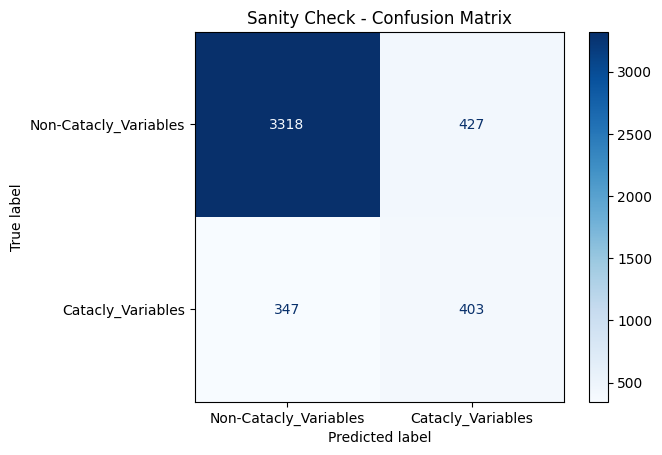

In [11]:
cm = confusion_matrix(y_true, y_pred, labels=[0,1])

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Non-Catacly_Variables", "Catacly_Variables"]
)

disp.plot(cmap=plt.cm.Blues)
plt.title("Sanity Check - Confusion Matrix")
plt.show()


In [13]:
from sklearn.metrics import f1_score

f1 = f1_score(y_true, y_pred, pos_label=1)
print("F1 Score (minority class):", f1)

F1 Score (minority class): 0.5101265822784811


In [16]:
from sklearn.metrics import f1_score

f1 = f1_score(y_true, y_pred, pos_label=0)
print("F1 Score (majority class):", f1)

F1 Score (majority class): 0.8955465587044534
